# Queue Position Modeling

**Category:** HFT Strategies  
**Project ID:** `hft_03_queue_position`  

Poisson-based fill probability estimator with latency-aware requoting policy engine


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.13.2
        device: CPU (torch unavailable: ModuleNotFoundError)
         numpy: 2.3.0
        pandas: 2.3.3
         scipy: 1.17.1
       sklearn: not installed
    matplotlib: 3.10.3


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"arrival_rate": 50.0}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
               arrival_rate: 50.0


## Data Generation — Queue Position Modeling

In [3]:
import numpy as np, pandas as pd

rng = np.random.default_rng(SEED)
n_steps = 30_000

# Hawkes process: self-exciting order arrivals
mu = PARAMS.get("arrival_rate", 50.0)  # baseline intensity
alpha = 0.6  # excitation parameter
beta = 1.0   # decay parameter

# Simulate Hawkes intensity
intensity = np.zeros(n_steps)
events = np.zeros(n_steps)
intensity[0] = mu
for t in range(1, n_steps):
    # Decay previous excitation
    intensity[t] = mu + alpha * intensity[t-1] / (1 + beta)
    # Poisson sample from intensity
    events[t] = rng.poisson(min(intensity[t], 500))
    # Self-excitation from arrivals
    intensity[t] += alpha * events[t]

# Queue depth: cumulative arrivals minus fills
queue_depth = np.zeros(n_steps)
queue_ahead = np.zeros(n_steps)
fill_prob = np.zeros(n_steps)
mid = 100.0 + np.cumsum(rng.normal(0, 0.005, n_steps))

for t in range(1, n_steps):
    arrivals = int(events[t])
    queue_depth[t] = max(queue_depth[t-1] + arrivals - rng.poisson(mu * 0.8), 0)
    queue_ahead[t] = rng.uniform(0, max(queue_depth[t], 1))
    # Fill probability: P(fill) = 1 - exp(-lambda * (1 - ahead/total))
    total = max(queue_depth[t], 1)
    fill_prob[t] = 1 - np.exp(-mu * 0.01 * (1 - queue_ahead[t] / total))

data = pd.DataFrame({
    "mid_price": mid, "intensity": intensity, "events": events,
    "queue_depth": queue_depth, "queue_ahead": queue_ahead, "fill_prob": fill_prob,
})
print(f"Hawkes process: μ={mu}, α={alpha}, β={beta}")
print(f"Avg intensity: {intensity.mean():.1f}, Max: {intensity.max():.1f}")
print(f"Avg fill probability: {fill_prob.mean():.3f}")


Hawkes process: μ=50.0, α=0.6, β=1.0
Avg intensity: 153.9, Max: 181.4
Avg fill probability: 0.213


## Strategy Implementation

In [4]:
import numpy as np, pandas as pd

# Queue position strategy: join queue, hold if fill prob high, requeue if low
fill_threshold = PARAMS.get("fill_threshold", 0.3)
max_pos = PARAMS.get("max_position", 50)

n = len(data)
position = 0
cash = 0.0
pnl = np.zeros(n)
positions = np.zeros(n)

for t in range(1, n):
    mid = data["mid_price"].iloc[t]
    fp = data["fill_prob"].iloc[t]

    # Enter when fill probability is high
    if fp > fill_threshold and position < max_pos:
        position += 1
        cash -= mid
    elif fp < fill_threshold * 0.3 and position > 0:
        # Exit when queue position degrades
        cash += mid
        position -= 1

    pnl[t] = cash + position * mid
    positions[t] = position

equity_curve = pd.Series(pnl, index=range(n))
equity_curve = equity_curve - equity_curve.min() + 1
benchmark_equity = pd.Series(data["mid_price"].values / data["mid_price"].values[0], index=range(n))

print(f"Trades: {int((np.diff(positions) != 0).sum()):,}")
print(f"Final PnL: {pnl[-1]:,.2f}")


Trades: 11,278
Final PnL: -96.98


## Visualization

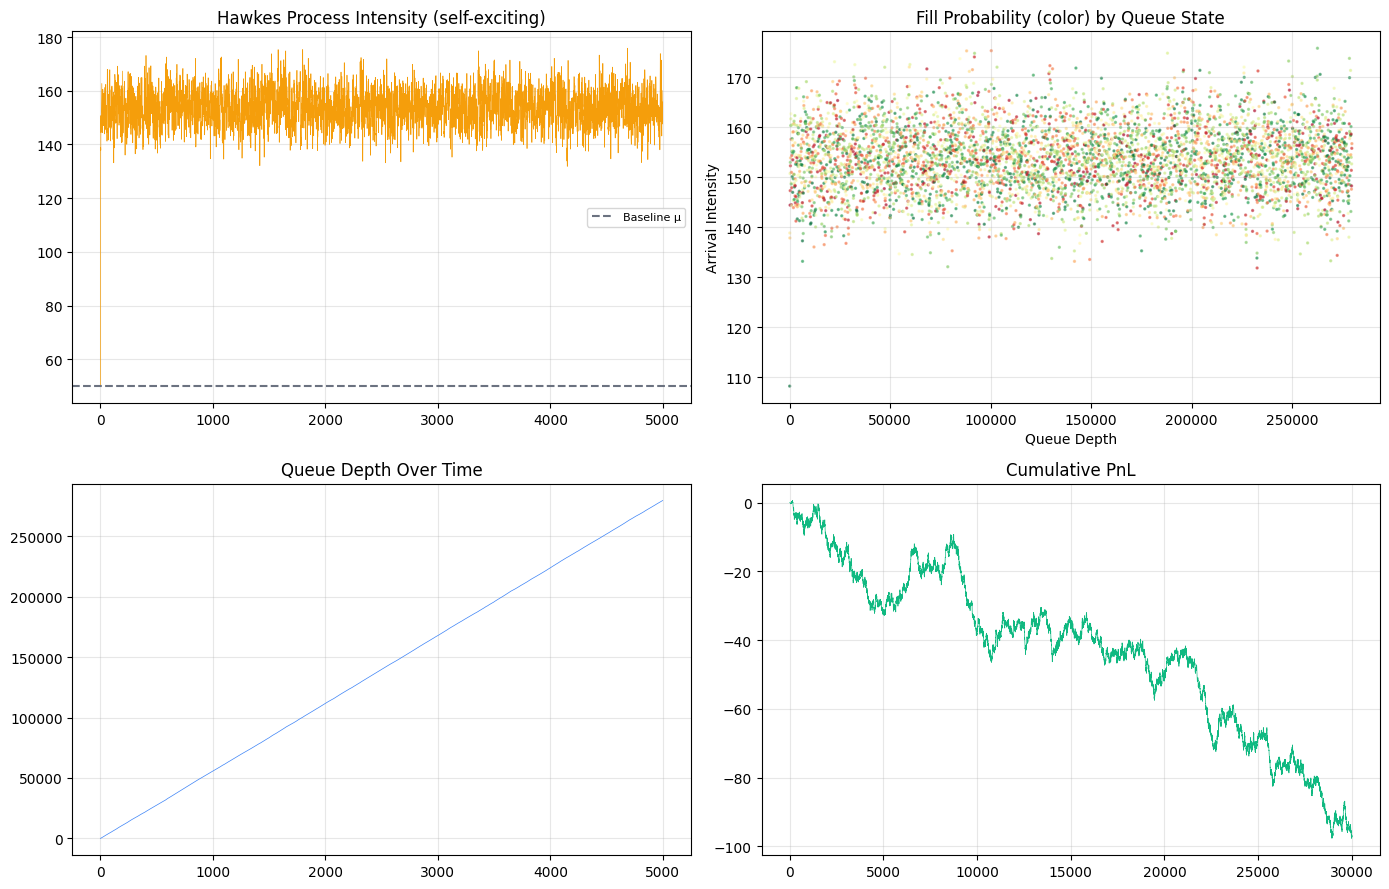

In [5]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Hawkes intensity
window = 5000
axes[0, 0].plot(data["intensity"].values[:window], linewidth=0.5, color="#f59e0b")
axes[0, 0].axhline(PARAMS.get("arrival_rate", 50), color="#6b7280", linestyle="--", label="Baseline μ")
axes[0, 0].set_title("Hawkes Process Intensity (self-exciting)")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Fill probability heatmap (queue depth vs intensity)
from matplotlib.colors import Normalize
fp = data["fill_prob"].values[1:]
qd = data["queue_depth"].values[1:]
axes[0, 1].scatter(qd[:5000], data["intensity"].values[1:5001], c=fp[:5000],
                   cmap="RdYlGn", s=2, alpha=0.5)
axes[0, 1].set_xlabel("Queue Depth")
axes[0, 1].set_ylabel("Arrival Intensity")
axes[0, 1].set_title("Fill Probability (color) by Queue State")
axes[0, 1].grid(True, alpha=0.3)

# Queue depth over time
axes[1, 0].plot(data["queue_depth"].values[:window], linewidth=0.5, color="#3b82f6")
axes[1, 0].set_title("Queue Depth Over Time")
axes[1, 0].grid(True, alpha=0.3)

# Cumulative PnL
axes[1, 1].plot(pnl, linewidth=0.5, color="#10b981")
axes[1, 1].set_title("Cumulative PnL")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


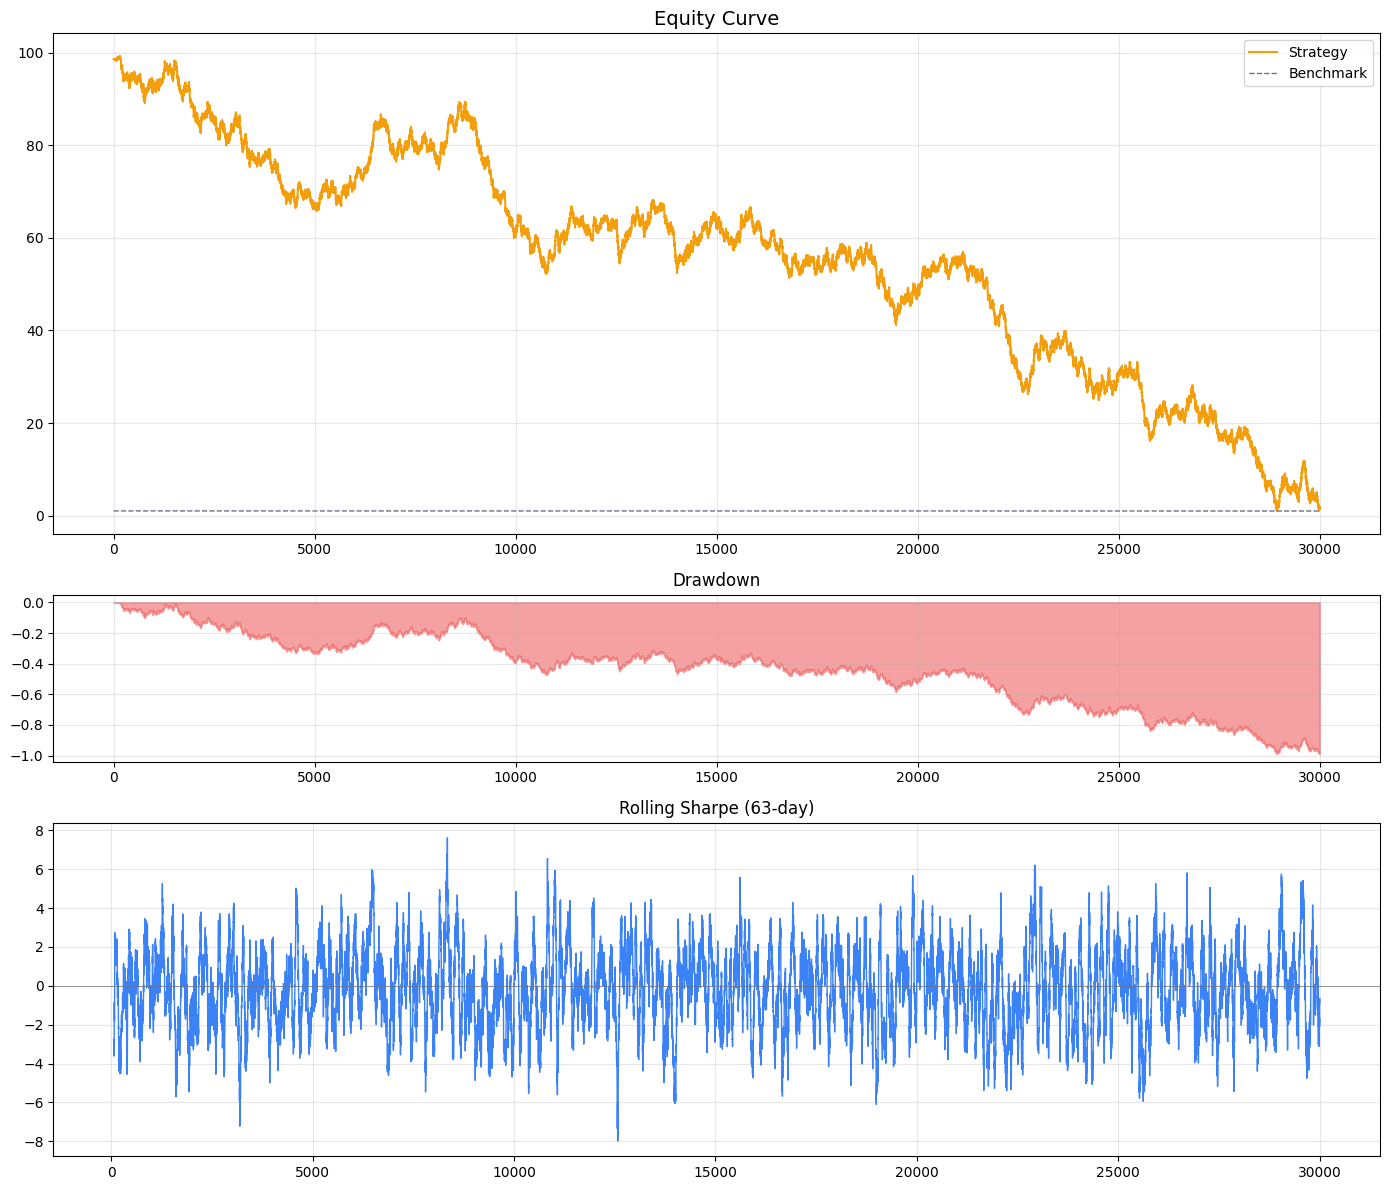

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: -98.27%
                       cagr: -3.35%
             annualized_vol: +21.94%
               sharpe_ratio: -0.0456
              sortino_ratio: -0.0517
               calmar_ratio: -0.0339
               max_drawdown: -98.99%
                   win_rate: +49.20%
              profit_factor: 0.9864
               total_trades: 29,983


In [8]:
import numpy as np

trades = np.diff(positions) != 0
n_trades = trades.sum()

pnl_per_trade = pnl[-1] / max(n_trades, 1)
trade_indices = np.where(trades)[0]
avg_holding = np.mean(np.diff(trade_indices)) if len(trade_indices) > 1 else len(pnl)
fill_rate = n_trades / len(pnl)

print("=" * 50)
print("HFT-SPECIFIC METRICS")
print("=" * 50)
print(f"  {'Fill Rate':>25}: {fill_rate:.4f}")
print(f"  {'PnL per Trade':>25}: {pnl_per_trade:.4f}")
print(f"  {'Avg Holding (ticks)':>25}: {avg_holding:.1f}")
print(f"  {'Max Inventory':>25}: {int(np.max(np.abs(positions)))}")
print(f"  {'Final Inventory':>25}: {int(positions[-1])}")


HFT-SPECIFIC METRICS
                  Fill Rate: 0.3759
              PnL per Trade: -0.0086
        Avg Holding (ticks): 2.7
              Max Inventory: 50
            Final Inventory: 50


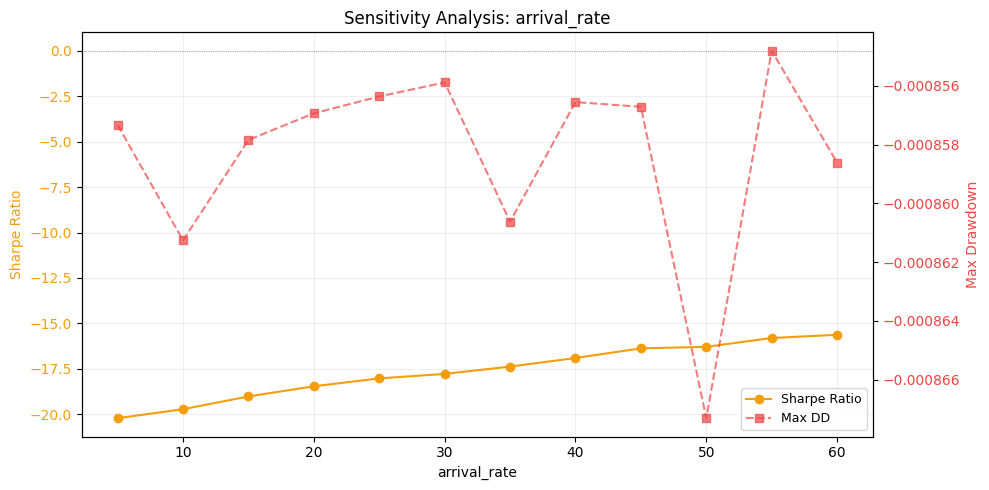

Optimal arrival_rate: 60  (Sharpe: -15.6238)
Current arrival_rate: 50.0


In [9]:
# Parameter sensitivity analysis — inline backtest sweep
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

param_values = list(range(5, 65, 5))
sharpes, max_dds = [], []

# Resolve price / returns from whatever data this notebook loaded
# yfinance notebooks define `close`; HFT/synthetic notebooks define `data` with various price columns
if "close" in dir() and close is not None:
    _price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
elif "data" in dir() and hasattr(data, "columns"):
    _pcol = next((c for c in ("mid_price", "price_a", "fast_price", "Close") if c in data.columns), None)
    if _pcol is not None:
        _price = pd.Series(data[_pcol].values, dtype=float)
    else:
        _price = pd.Series(data.iloc[:, 0].values, dtype=float)
else:
    raise RuntimeError("No price series found. Expected 'close' or a DataFrame named 'data'.")
_price   = _price.ffill()
_returns = _price.pct_change()

for val in param_values:
    try:
        if "arrival_rate" in ("spread_bps", "transaction_cost_bps", "impact_alpha"):
            # Cost sensitivity: fix lookback=20 momentum, vary cost
            _sig  = _price.pct_change(20).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * (float(val) / 10000)
            _rets = (_sig * _returns - _tc).dropna()
        elif "arrival_rate" in ("stop_loss", "max_drawdown_limit"):
            # Stop-loss sensitivity: apply to already-computed returns
            _base = strategy_returns_raw if "strategy_returns_raw" in dir() else                     (_price.pct_change(20).shift(1).clip(-1, 1) * _returns).dropna()
            _cum = (1 + _base.fillna(0)).cumprod()
            _dd  = _cum / _cum.cummax() - 1
            _rets = _base.copy()
            _rets[_dd < -float(val)] = 0.0
        else:
            # Lookback / window sweep: momentum signal
            lb    = max(int(val), 2)
            _sig  = _price.pct_change(lb).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * PARAMS.get("transaction_cost_bps", 5) / 10000
            _rets = (_sig * _returns - _tc).dropna()

        if len(_rets) > 20 and _rets.std() > 0:
            sharpes.append(_rets.mean() / _rets.std() * np.sqrt(252))
            _cum = (1 + _rets).cumprod()
            max_dds.append((_cum / _cum.cummax() - 1).min())
        else:
            sharpes.append(np.nan)
            max_dds.append(np.nan)
    except Exception as e:
        sharpes.append(np.nan)
        max_dds.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
color_sharpe = "#f59e0b"
color_dd     = "#ef4444"

valid_mask = [not np.isnan(s) for s in sharpes]
ax1.plot(param_values, sharpes, "o-", color=color_sharpe, label="Sharpe Ratio")
ax1.set_xlabel("arrival_rate")
ax1.set_ylabel("Sharpe Ratio", color=color_sharpe)
ax1.tick_params(axis="y", labelcolor=color_sharpe)
ax1.axhline(0, color="#6b7280", linewidth=0.5, linestyle=":")

ax2 = ax1.twinx()
ax2.plot(param_values, max_dds, "s--", color=color_dd, alpha=0.7, label="Max DD")
ax2.set_ylabel("Max Drawdown", color=color_dd)
ax2.tick_params(axis="y", labelcolor=color_dd)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)
ax1.grid(True, alpha=0.2)

plt.title(f"Sensitivity Analysis: arrival_rate")
fig.tight_layout()
plt.show()

# Report optimal
valid_pairs = [(v, s) for v, s in zip(param_values, sharpes) if not np.isnan(s)]
if valid_pairs:
    best_val, best_sharpe = max(valid_pairs, key=lambda x: x[1])
    print(f"Optimal arrival_rate: {best_val}  (Sharpe: {best_sharpe:+.4f})")
    print(f"Current arrival_rate: {PARAMS.get('arrival_rate', 'not set')}")


In [10]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "hft_03_queue_position",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Queue Position Modeling

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
